<a href="https://colab.research.google.com/github/Pragya27apoorva/Basic-Info/blob/main/sleep_pattern_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the dataset
data = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

In [ ]:
# Displaying initial data information
print("Initial Data Information:")
data.info()
print("\nFirst 5 rows of the data:")
print(data.head())

# Descriptive statistics
descriptive_stats = data.describe()

# Unique values in each categorical column
unique_values = {}
cat_columns = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder', 'Blood Pressure']
for col in cat_columns:
    unique_values[col] = data[col].unique()

display(descriptive_stats, unique_values)

# Correcting the inconsistency in 'BMI Category'
data['BMI Category'].replace({'Normal Weight': 'Normal'}, inplace=True)

# Splitting the 'Blood Pressure' column into 'Systolic' and 'Diastolic' columns
data['Systolic'] = data['Blood Pressure'].str.split('/').str[0].astype(int)
data['Diastolic'] = data['Blood Pressure'].str.split('/').str[1].astype(int)
data.drop(['Blood Pressure', 'Person ID'], axis=1, inplace=True)

Initial Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


{'Gender': array(['Male', 'Female'], dtype=object),
 'Occupation': array(['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher',
        'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer',
        'Salesperson', 'Manager'], dtype=object),
 'BMI Category': array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object),
 'Sleep Disorder': array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object),
 'Blood Pressure': array(['126/83', '125/80', '140/90', '120/80', '132/87', '130/86',
        '117/76', '118/76', '128/85', '131/86', '128/84', '115/75',
        '135/88', '129/84', '130/85', '115/78', '119/77', '121/79',
        '125/82', '135/90', '122/80', '142/92', '140/95', '139/91',
        '118/75'], dtype=object)}

/tmp/ipython-input-3444601132.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['BMI Category'].replace({'Normal Weight': 'Normal'}, inplace=True)


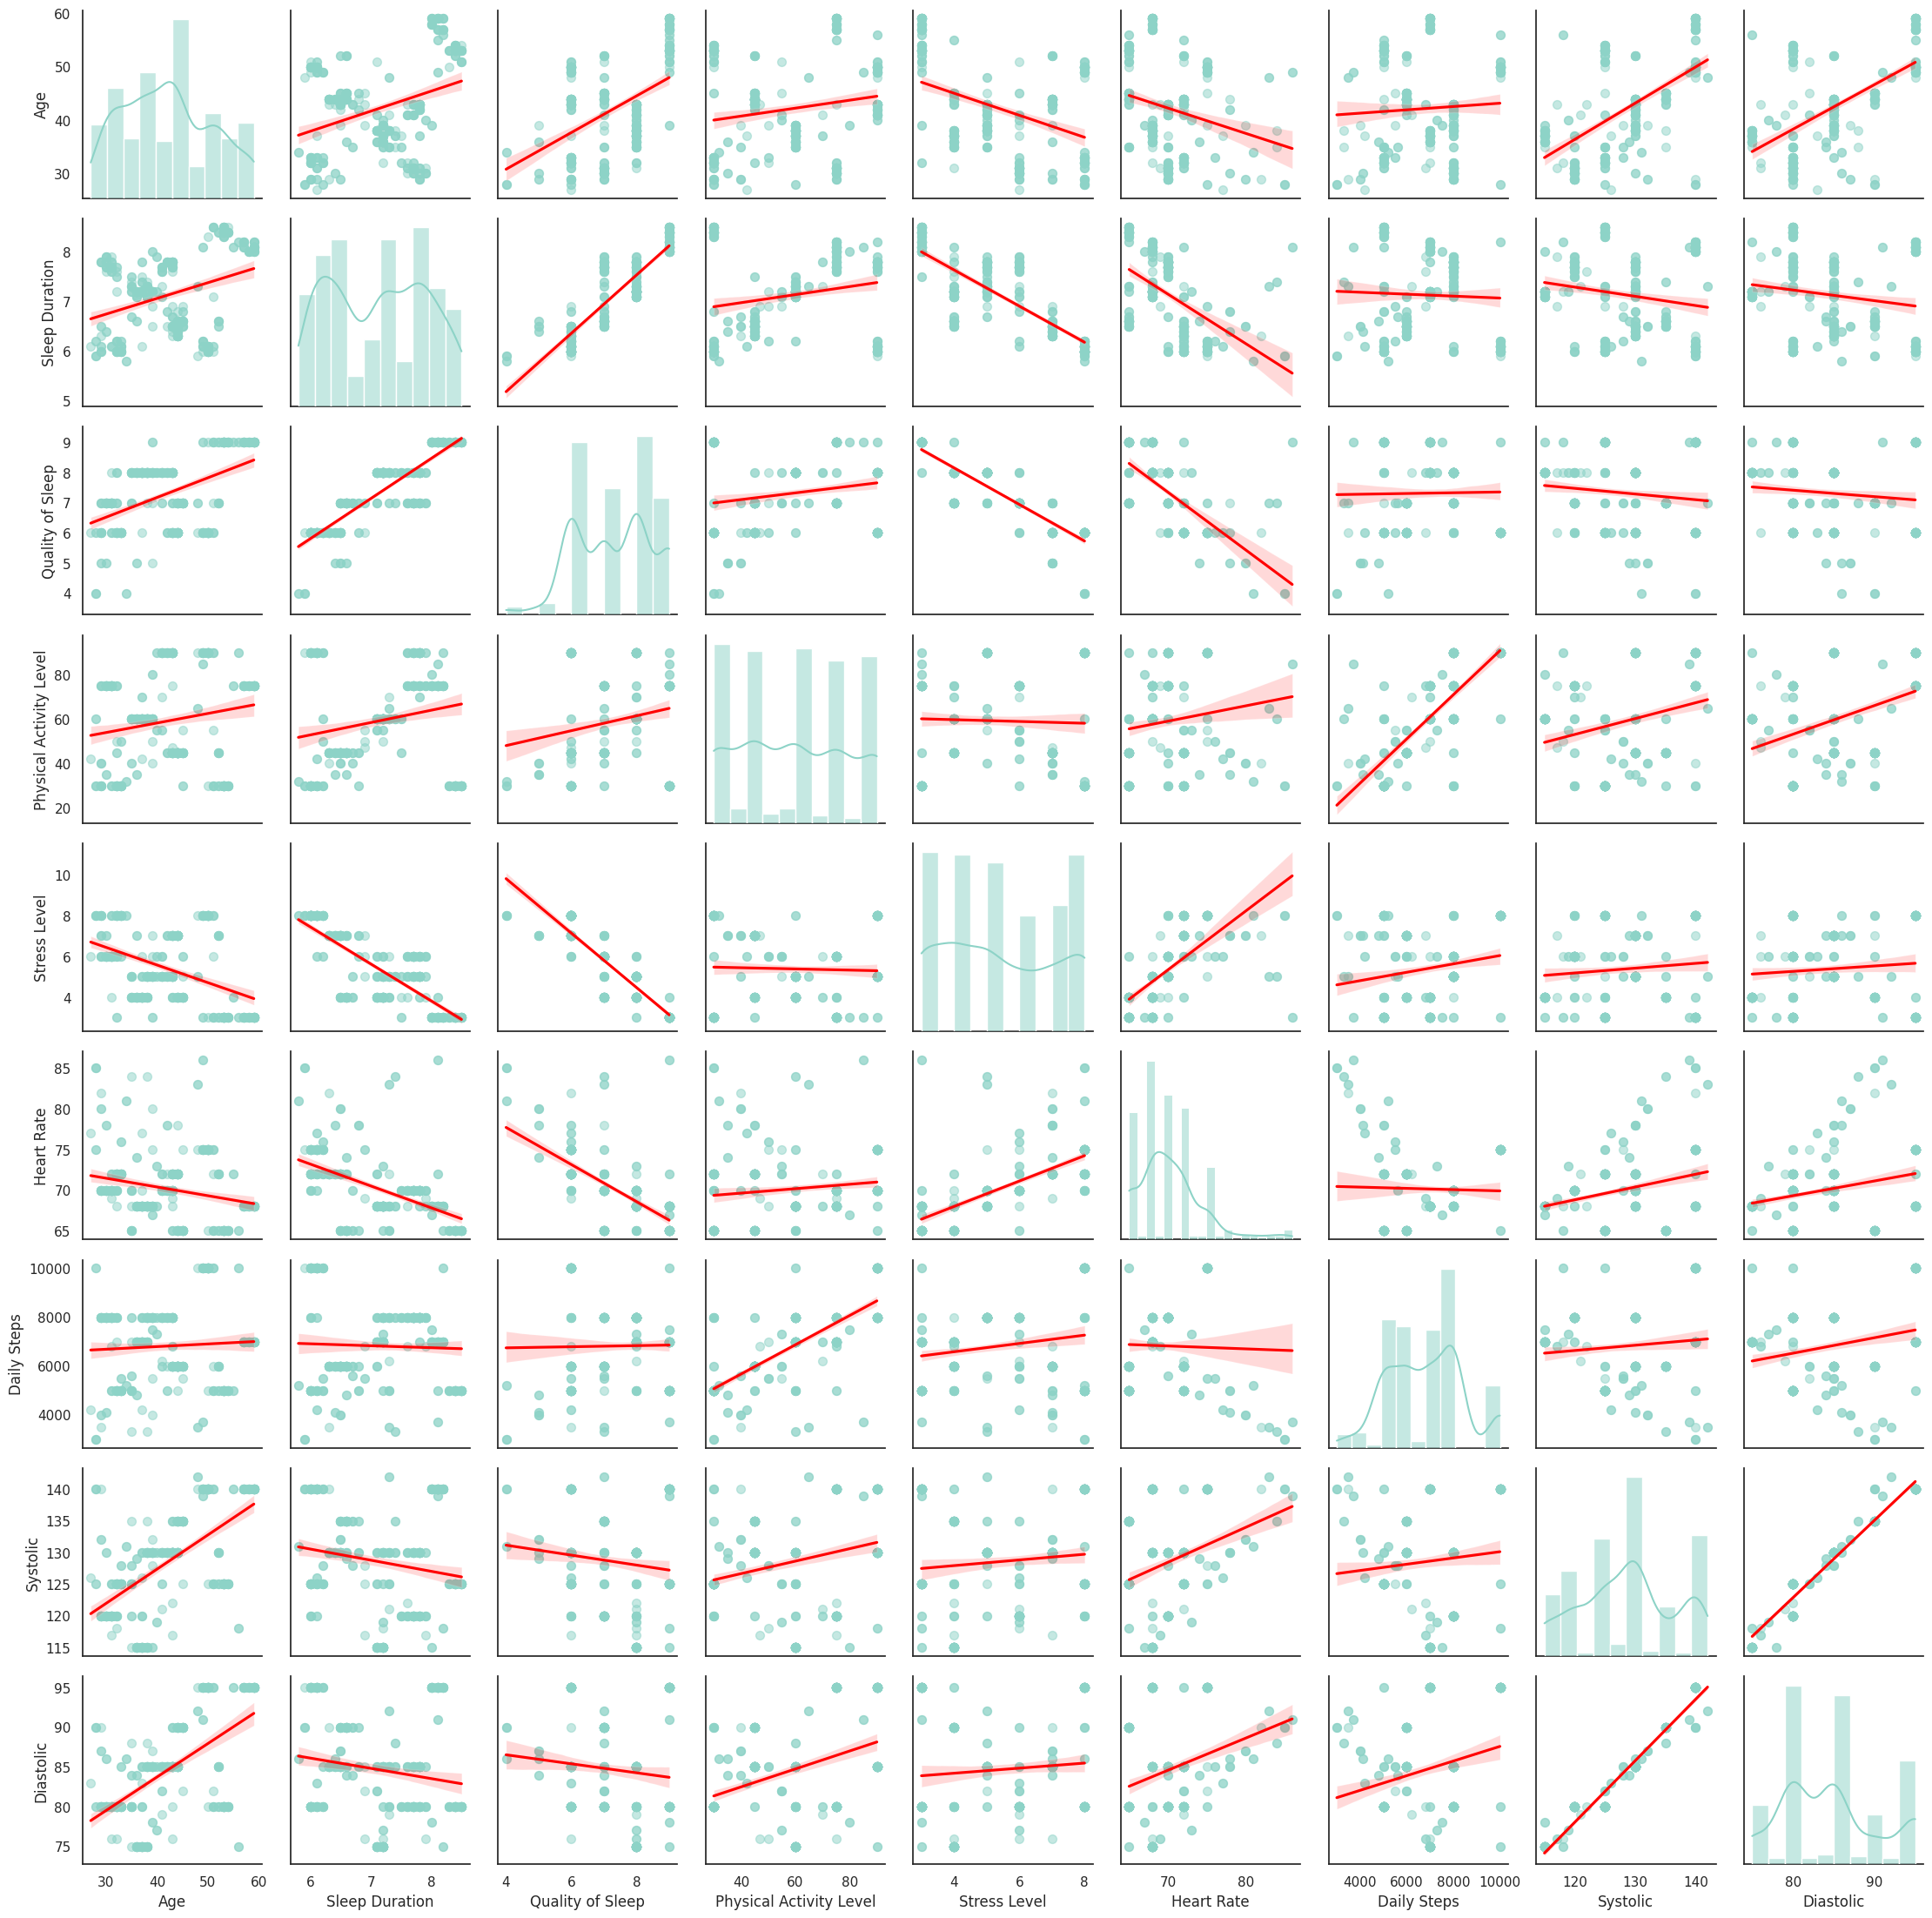

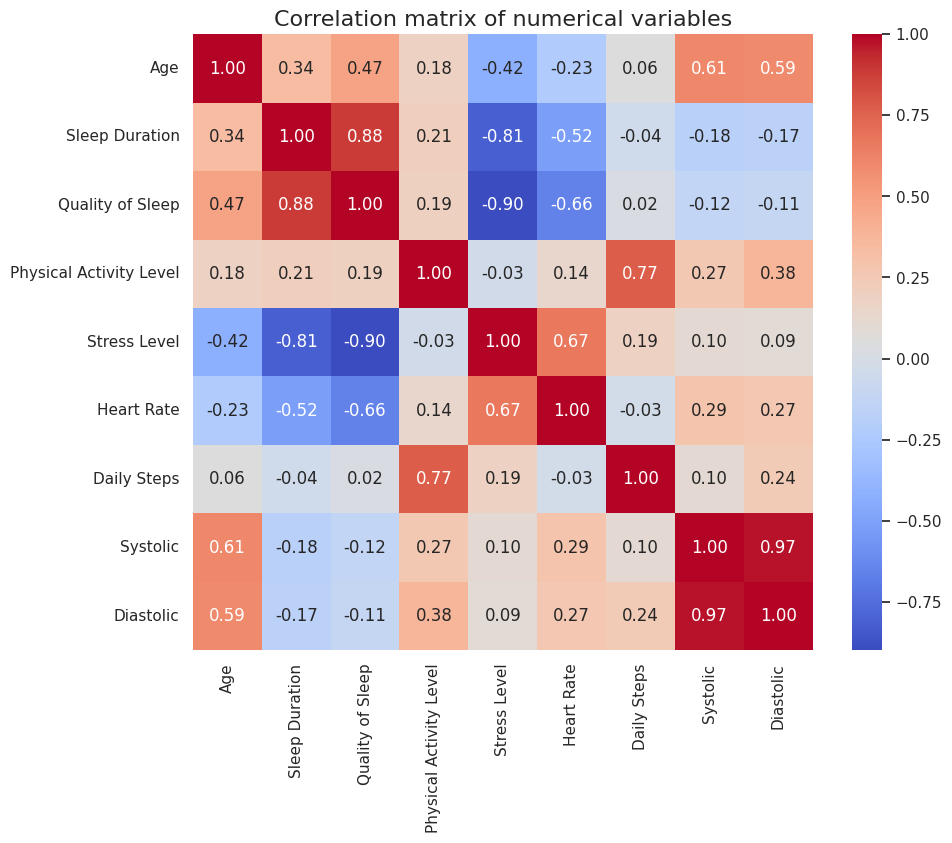

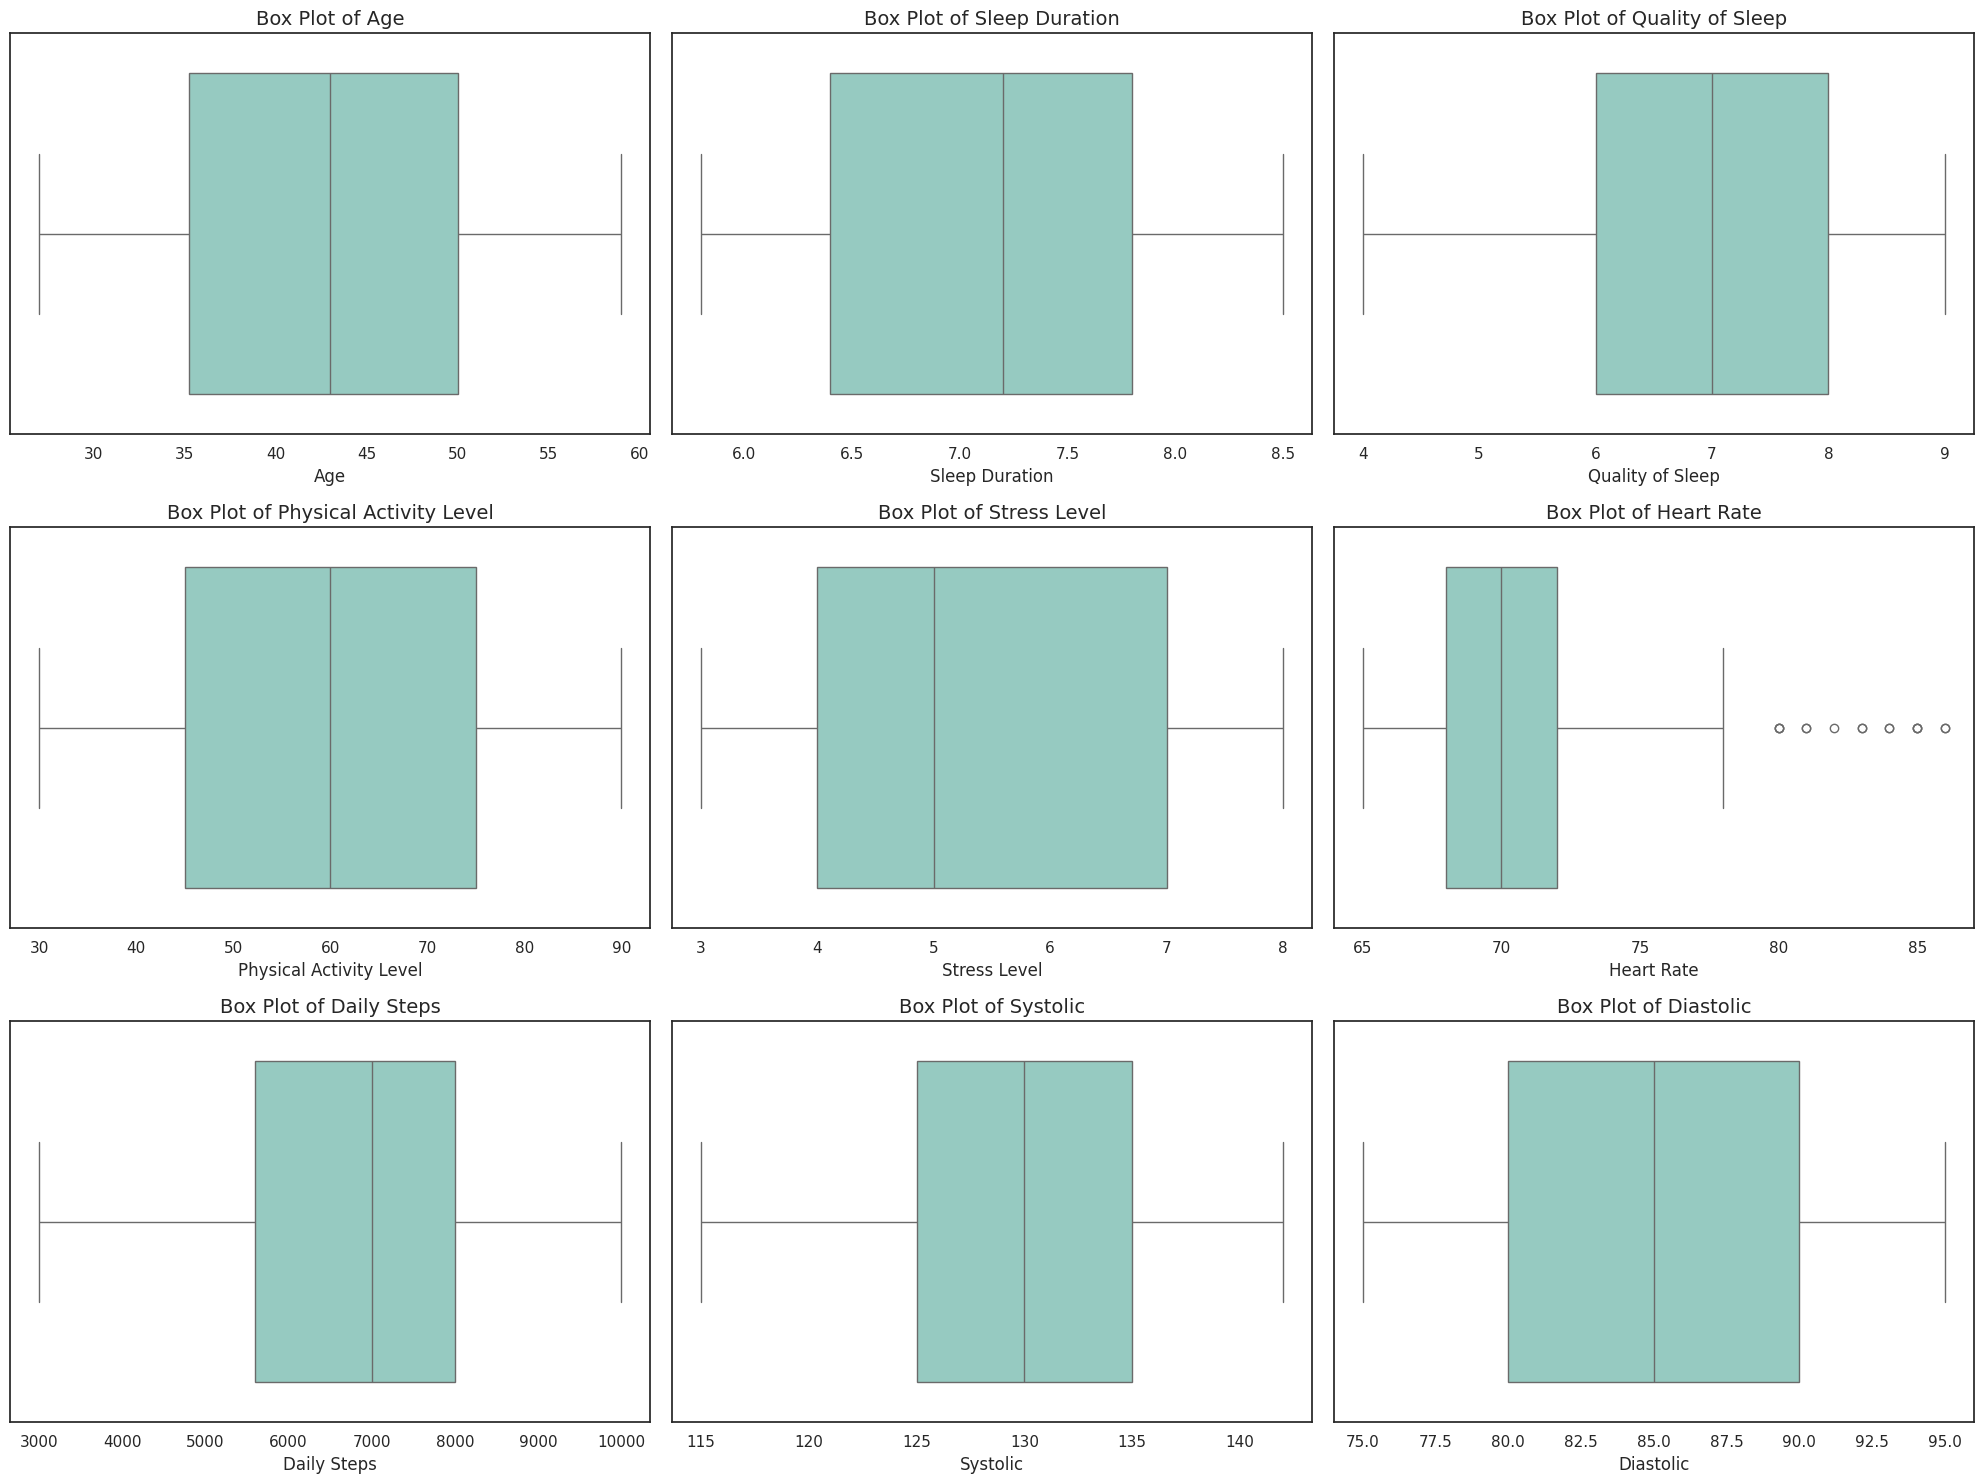

/tmp/ipython-input-1628188508.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-1628188508.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-1628188508.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)


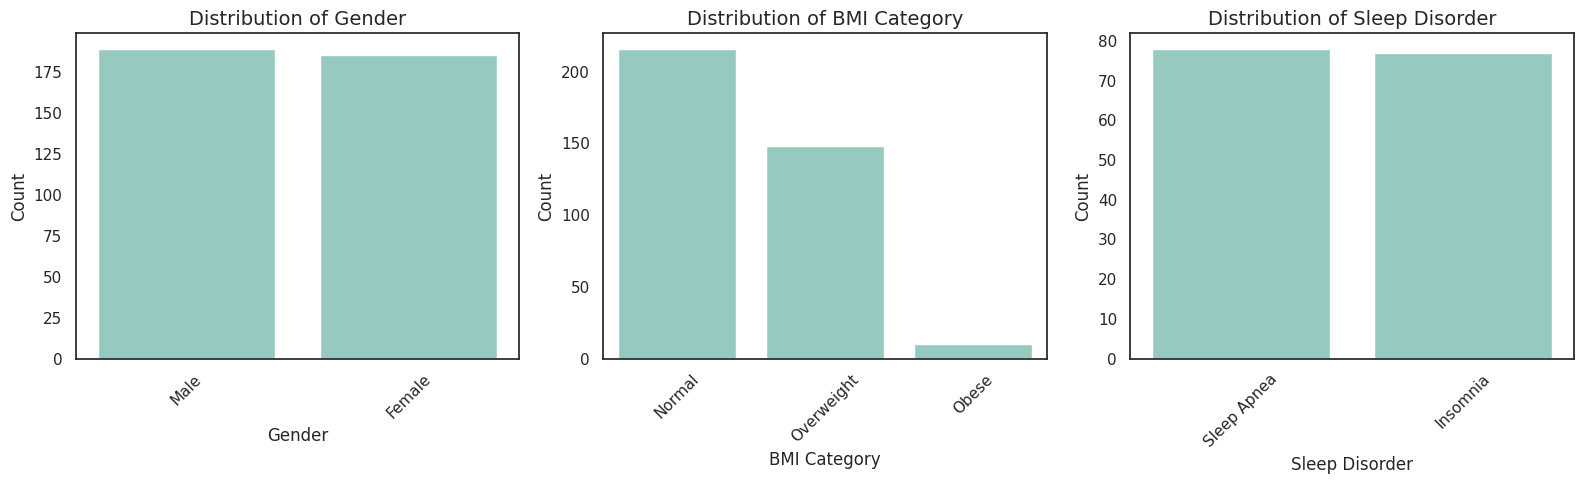

/tmp/ipython-input-1628188508.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


The 'Sleep Disorder' column does not contain 'None'. Please check the values.


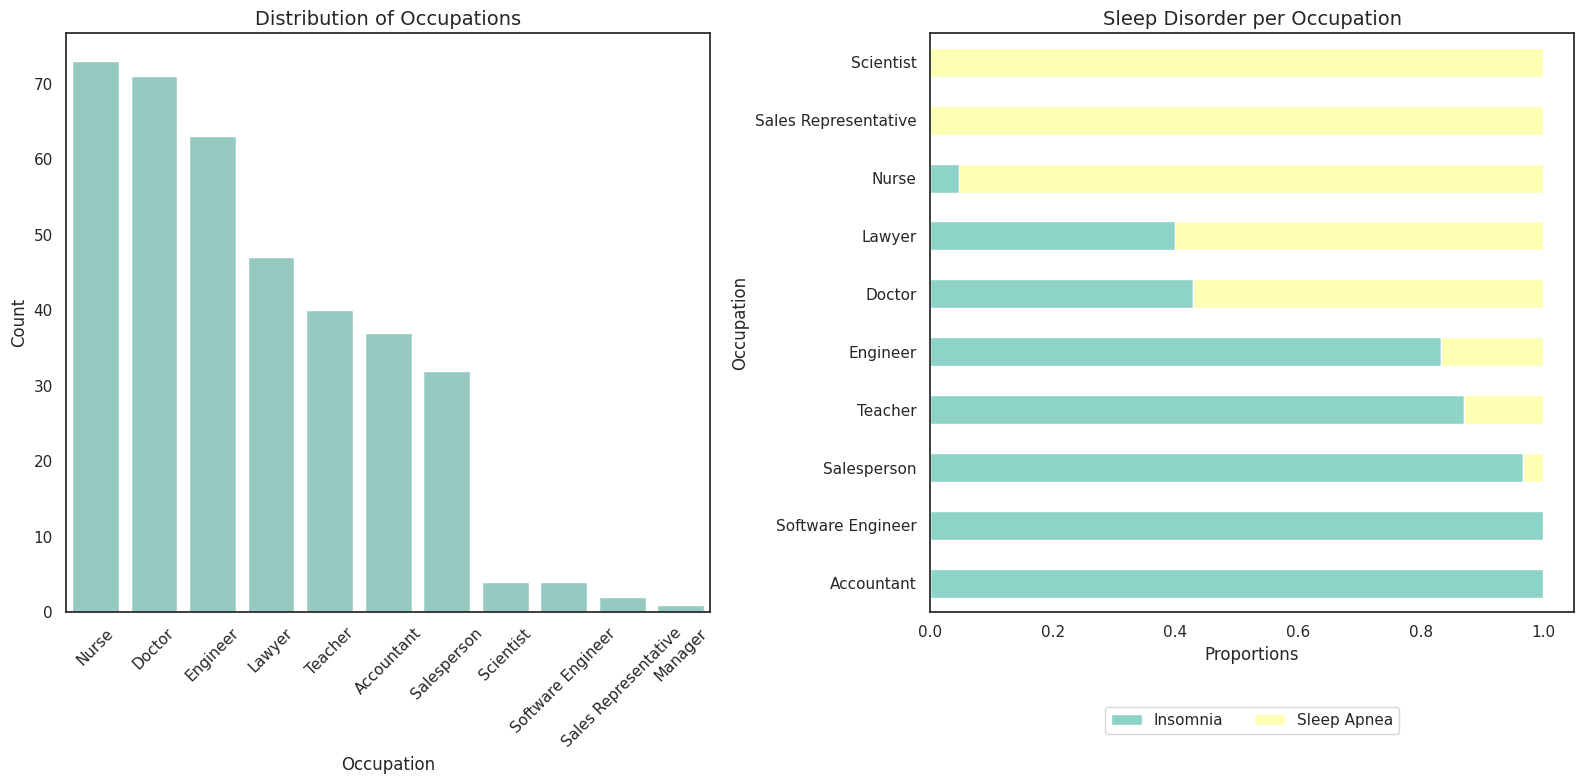

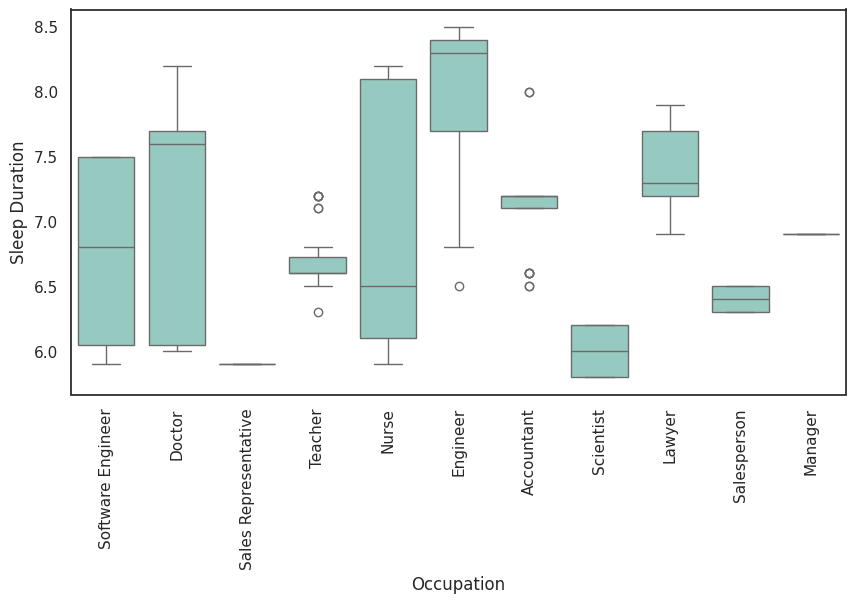

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white")
sns.set_palette(palette='Set3')

# List of key numerical variables
num_vars = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# PairGrid instance, mapping a histogram+KDE to the diagonal and regplot to the off-diagonal elements
pair_grid = sns.PairGrid(data=data[num_vars], diag_sharey=False)
pair_grid.map_diag(sns.histplot, kde=True)
pair_grid.map_offdiag(sns.regplot, scatter_kws={'s': 50, 'alpha': 0.5}, line_kws={'color': 'red'})
plt.show()

# Correlation matrix
corr_matrix = data[num_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation matrix of numerical variables', fontsize=16)
plt.show()

# Box plots to identify any outliers
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
for i, var in enumerate(num_vars):
    row = i // 3
    col = i % 3
    sns.boxplot(x=data[var], ax=axes[row, col])
    axes[row, col].set_title(f'Box Plot of {var}', fontsize=14)
    axes[row, col].set_xlabel(var, fontsize=12)
plt.tight_layout()
plt.show()

# Distribution of categorical variables
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))
for i, var in enumerate(['Gender', 'BMI Category', 'Sleep Disorder']):
    order = data[var].value_counts().index
    sns.countplot(x=var, data=data, ax=axes[i], order=order)
    axes[i].set_title(f'Distribution of {var}', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

# Distribution of Sleep Disorder per Occupation variable
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
order = data['Occupation'].value_counts().index
sns.countplot(x='Occupation', data=data, ax=ax1, order=order)
ax1.set_title('Distribution of Occupations', fontsize=14)
ax1.set_xlabel('Occupation', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Corrected part:
# Ensure the 'None' category exists before plotting
if 'None' not in data['Sleep Disorder'].unique():
    # If it doesn't exist, we assume 'None' corresponds to no sleep disorder
    # This might require re-examining the data or adding it as a category.
    # For now, let's assume it was a typo and the original data has a different label
    # or that the intent was to sort by the most common category (likely 'None'
    # if it's the largest group).
    # A safer approach is to get the list of unique categories and handle the sort dynamically.

    unique_sleep_disorders = data['Sleep Disorder'].unique().tolist()

    # Check if 'None' is a valid category after pre-processing
    if 'None' not in unique_sleep_disorders:
        print("The 'Sleep Disorder' column does not contain 'None'. Please check the values.")
        # We can try to proceed by sorting based on a different category
        # or skipping this plot.

    occup_dis = data.groupby('Occupation')['Sleep Disorder'].value_counts(normalize=True).unstack(fill_value=0)

    # Sort the dataframe by the proportion of the 'None' category
    if 'None' in occup_dis.columns:
        occup_dis = occup_dis.sort_values(by='None', ascending=False)
    else:
        # Fallback sorting, e.g., by total count or alphabetically
        occup_dis = occup_dis.sort_values(by=occup_dis.columns[0], ascending=False)

    order_sleep_disorder = occup_dis.columns.tolist()

    occup_dis[order_sleep_disorder].plot(kind='barh', stacked=True, ax=ax2)
    ax2.set_title('Sleep Disorder per Occupation', fontsize=14)
    ax2.set_xlabel('Proportions', fontsize=12)
    ax2.set_ylabel('Occupation', fontsize=12)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=data, y='Sleep Duration', x='Occupation')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Separating features (X) and target variable (y)
X = data.drop(['Sleep Disorder'], axis=1)
y = data['Sleep Disorder']

# Label encoding for categorical variables in X
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encoding the target variable
le_target = LabelEncoder()
y = le_target.fit_transform(y)
print("Encoded features (X) and target (y):")
print(X.head())
print(y[:5])

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Applying StandardScaler to Numerical Variables
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
num_vars = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_train_scaled[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test_scaled[num_vars] = scaler.transform(X_test[num_vars])

Encoded features (X) and target (y):
   Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0       1   27           9             6.1                 6   
1       1   28           1             6.2                 6   
2       1   28           1             6.2                 6   
3       1   28           6             5.9                 4   
4       1   28           6             5.9                 4   

   Physical Activity Level  Stress Level  BMI Category  Heart Rate  \
0                       42             6             2          77   
1                       60             8             0          75   
2                       60             8             0          75   
3                       30             8             1          85   
4                       30             8             1          85   

   Daily Steps  Systolic  Diastolic  
0         4200       126         83  
1        10000       125         80  
2        10000       125         80  
3    

LogisticRegression Cross-Validation F1_weighted: 0.90 +/- 0.03
LogisticRegression Classification Report:
              precision    recall  f1-score   support

        None       0.75      0.80      0.77        15
 Sleep Apnea       0.78      0.88      0.82        16
    Insomnia       0.98      0.91      0.94        44

    accuracy                           0.88        75
   macro avg       0.83      0.86      0.85        75
weighted avg       0.89      0.88      0.88        75



RidgeClassifier Cross-Validation F1_weighted: 0.88 +/- 0.03
RidgeClassifier Classification Report:
              precision    recall  f1-score   support

        None       0.67      0.80      0.73        15
 Sleep Apnea       0.75      0.75      0.75        16
    Insomnia       0.98      0.91      0.94        44

    accuracy                           0.85        75
   macro avg       0.80      0.82      0.81        75
weighted avg       0.87      0.85      0.86        75



SVC Cross-Validation F1_weight

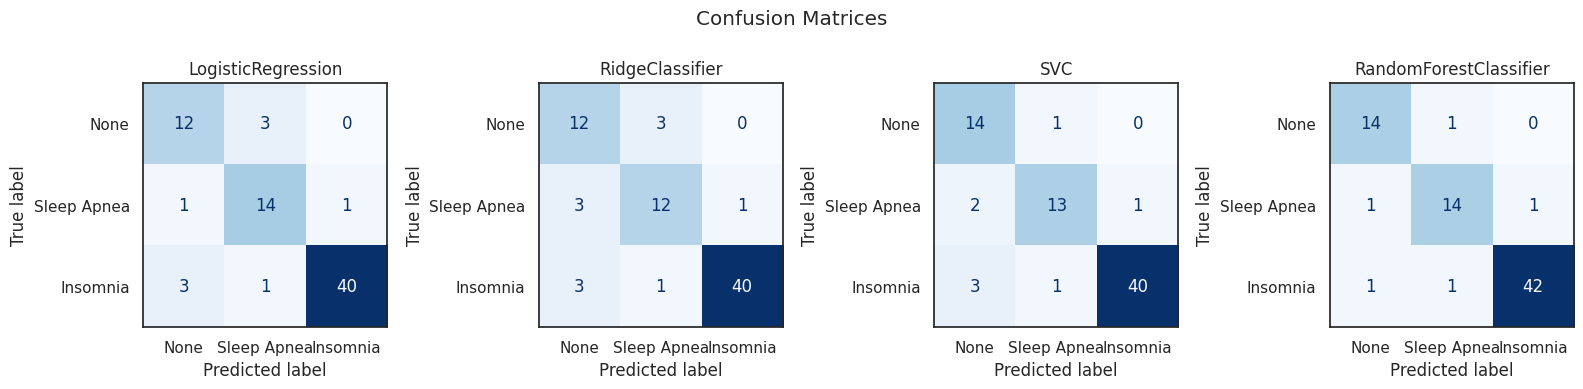

In [ ]:
# Function to train and validate models
def train_and_cross_validate(model, X_train, y_train, cv=5):
    """
    Function to train the models using cross-validation and return the average score.
    """
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
    print(f"{model.__class__.__name__} Cross-Validation F1_weighted: {np.mean(scores):.2f} +/- {np.std(scores):.2f}")
    model.fit(X_train, y_train)
    return model

# Function to evaluate and plot models
def evaluate_and_plot_confusion_matrix(model, X_test, y_test, class_names, ax):
    """
    Evaluate the model and plot the confusion matrix.
    """
    y_pred = model.predict(X_test)
    print(f"{model.__class__.__name__} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    print("\n" + "="*80 + "\n")

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    disp.im_.colorbar.remove()
    ax.set_title(f"{model.__class__.__name__}")

# Defining class names for confusion matrix display
class_names = ['None', 'Sleep Apnea', 'Insomnia']
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
axes = axes.flatten()

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, class_weight='balanced'),
    "Ridge Classifier": RidgeClassifier(class_weight='balanced'),
    "SVM": SVC(class_weight='balanced', kernel='linear'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)
}

# Iterate over models, cross-validate, train, predict, and generate classification report and confusion matrix
for i, (name, model) in enumerate(models.items()):
    X_train_set, X_test_set = (X_train_scaled, X_test_scaled) if name in ["Logistic Regression", "Ridge Classifier", "SVM"] else (X_train, X_test)

    trained_model = train_and_cross_validate(model, X_train_set, y_train)
    evaluate_and_plot_confusion_matrix(trained_model, X_test_set, y_test, class_names, axes[i])

fig.suptitle('Confusion Matrices')
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}


LogisticRegression Classification Report:
              precision    recall  f1-score   support

        None       0.75      0.80      0.77        15
 Sleep Apnea       0.78      0.88      0.82        16
    Insomnia       0.98      0.91      0.94        44

    accuracy                           0.88        75
   macro avg       0.83      0.86      0.85        75
weighted avg       0.89      0.88      0.88        75



Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters for Ridge Classifier: {'alpha': 10.0}


RidgeClassifier Classification Report:
              precision    recall  f1-score   support

        None       0.67      0.80      0.73        15
 Sleep Apnea       0.75      0.75      0.75        16
    Insomnia       0.98      0.91      0.94        44

    accuracy                           0.85        75
   macro avg    

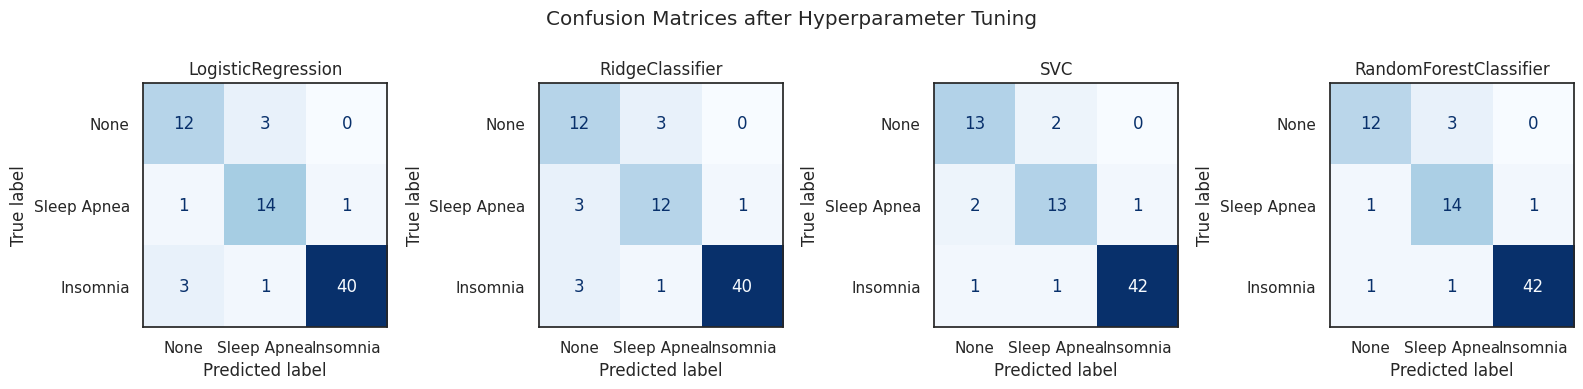

In [ ]:
# Creating a function to perform grid search on models
def perform_grid_search(model, params, X_train, y_train):
    """
    Perform grid search for hyperparameter tuning.
    """
    grid_search = GridSearchCV(model, params, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_, grid_search.best_params_

# Model parameters and configurations for grid search
param_grids = {
    "Logistic Regression": {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'saga']},
    "Ridge Classifier": {'alpha': [0.1, 1.0, 10.0]},
    "SVM": {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }
}

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
axes = axes.flatten()

# Model training, hyperparameter tuning, evaluation, and plotting
for i, (name, model) in enumerate(models.items()):
    X_train_set, X_test_set = (X_train_scaled, X_test_scaled) if name in ["Logistic Regression", "Ridge Classifier", "SVM"] else (X_train, X_test)

    best_model, best_params = perform_grid_search(model, param_grids[name], X_train_set, y_train)
    print(f"Best Parameters for {name}: {best_params}")
    print("\n" + "="*80 + "\n")
    evaluate_and_plot_confusion_matrix(best_model, X_test_set, y_test, class_names, axes[i])

fig.suptitle('Confusion Matrices after Hyperparameter Tuning')
plt.tight_layout()
plt.show()

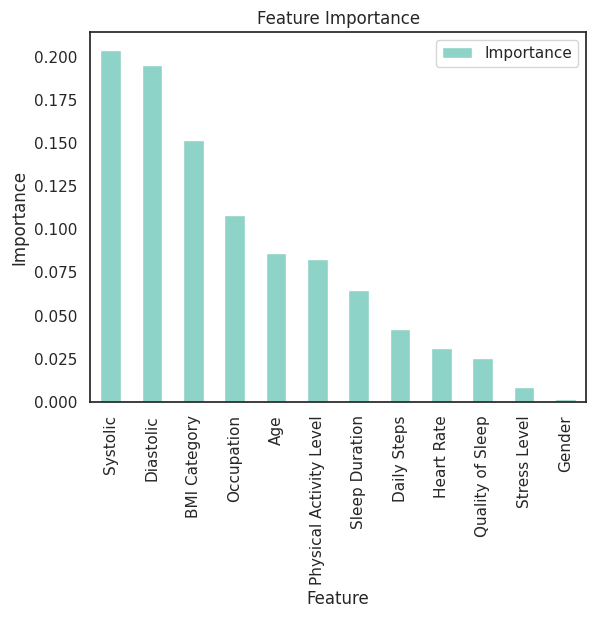

In [ ]:
# Training RandomForestClassifier to extract feature importance
# Using the best parameters from the grid search
rf_best = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=50, max_depth=None, max_features='sqrt', min_samples_leaf=1, min_samples_split=10, bootstrap=True)

rf_best.fit(X_train, y_train)

feature_importances = rf_best.feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

features_df.sort_values(by='Importance', ascending=False).plot(x='Feature', y='Importance', kind='bar')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:44:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:44:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:44:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:44:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:44:01] WARNING: /w

XGBClassifier Cross-Validation F1_weighted: 0.89 +/- 0.02


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:44:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier Classification Report:
              precision    recall  f1-score   support

        None       0.88      0.93      0.90        15
 Sleep Apnea       0.88      0.88      0.88        16
    Insomnia       0.98      0.95      0.97        44

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.93      0.93      0.93        75





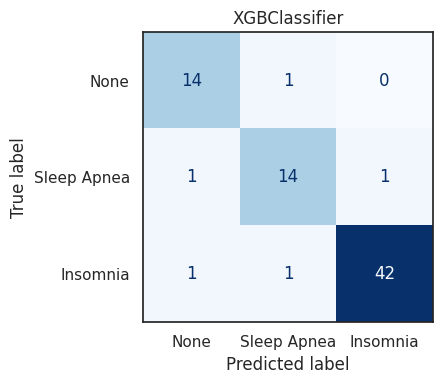

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:44:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
XGBClassifier Classification Report:
              precision    recall  f1-score   support

        None       0.88      0.93      0.90        15
 Sleep Apnea       0.88      0.88      0.88        16
    Insomnia       0.98      0.95      0.97        44

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.93      0.93      0.93        75





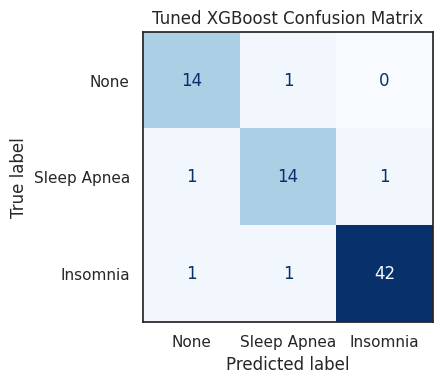

In [ ]:
# Install XGBoost if not installed
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Initialize XGBoost model
xgb_model = XGBClassifier(
    objective='multi:softmax',  # multiclass classification
    num_class=3,                # because we have 3 classes (None, Sleep Apnea, Insomnia)
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Cross-validation and training
xgb_model = train_and_cross_validate(xgb_model, X_train_scaled, y_train)

# Evaluate and visualize results
fig, ax = plt.subplots(figsize=(5, 4))
evaluate_and_plot_confusion_matrix(xgb_model, X_test_scaled, y_test, class_names, ax)
plt.tight_layout()
plt.show()

# Optional: Hyperparameter tuning using GridSearchCV
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

best_xgb_model, best_xgb_params = perform_grid_search(xgb_model, xgb_params, X_train_scaled, y_train)
print(f"Best Parameters for XGBoost: {best_xgb_params}")

# Evaluate tuned XGBoost
fig, ax = plt.subplots(figsize=(5, 4))
evaluate_and_plot_confusion_matrix(best_xgb_model, X_test_scaled, y_test, class_names, ax)
plt.title('Tuned XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()
